In [2]:
import numpy as np
import scipy.integrate as integrate
import scipy.linalg as linalg
import matplotlib.pyplot as plt
import warnings

In [3]:
warnings.filterwarnings('ignore', category=integrate.IntegrationWarning)

In [4]:
RT2 = np.sqrt(2)

V1 = -1/4
V4 = 4
SQRT_M_V1 = 0.5

sqrt_term = np.sqrt(2 + 2j)
E1 = -1.0 - sqrt_term + 1j
E2 = -1.0 + sqrt_term + 1j


INTEGRATION_BOUND = 20.0

In [5]:
def integrate_complex(func, a, b):
    """
    Integrates a complex function by splitting it into real and imaginary parts.
    """
    def real_part(x):
        return np.real(func(x))
    
    def imag_part(x):
        return np.imag(func(x))

    
    limit = 200
    
    real_integral = integrate.quad(real_part, -INTEGRATION_BOUND, INTEGRATION_BOUND, limit=limit)[0]
    imag_integral = integrate.quad(imag_part, -INTEGRATION_BOUND, INTEGRATION_BOUND, limit=limit)[0]
    
    return real_integral + 1j * imag_integral


def theta_func(x):
    """ The function theta from Eq. 12 """
    return np.arctan(np.tanh(x/2.0))

# num1 = 8*sqrt(-V1) - 4 + 4*sqrt_term
num1 = 8*SQRT_M_V1 - 4.0 + 4.0*sqrt_term
# num2 = 8*sqrt(-V1) - 4 - 4*sqrt_term
num2 = 8*SQRT_M_V1 - 4.0 - 4.0*sqrt_term
# den = 8 + 8i*V4
den = 8.0 + 8.0j*V4

C1 = num1 / den
C2 = num2 / den

In [6]:


def psi_1(x):
    th = theta_func(x)
    common_factor = np.exp(1j*SQRT_M_V1*np.sinh(x) - (V4/2.0)*th) / (np.cosh(x)**1.5)
    poly_part = 1.0 + C1 * (1.0 - 1j*np.sinh(x))
    return common_factor * poly_part

def psi_2(x):
    th = theta_func(x)
    common_factor = np.exp(1j*SQRT_M_V1*np.sinh(x) - (V4/2.0)*th) / (np.cosh(x)**1.5)
    poly_part = 1.0 + C2 * (1.0 - 1j*np.sinh(x))
    return common_factor * poly_part


--- Step 1: Normalization (PT-Broken Basis) ---
Norm of psi_1: 2.2394
Overlap <phi_1 | psi_2>: 1.0748+0.1095j
... Applying Gram-Schmidt.

--- Steps 2 & 3: Calculating X and H Matrices ---
X Matrix (Position):
[[-0.9813+0.j      0.7331+0.3773j]
 [ 0.7331-0.3773j -2.0535+0.j    ]]
Is X Hermitian? True

H Matrix (in orthonormal {phi_1, phi_2} basis):
[[-2.5538+0.3564j  4.3013+2.3175j]
 [-0.    +0.j      0.5538+1.6436j]]
Is H Hermitian? False
... DIAGNOSTIC: H is NOT Hermitian, as expected.

Diagonalized Eigenvalues: [-2.5538+0.3564j  0.5538+1.6436j]
... DIAGNOSTIC: The eigenvalues are COMPLEX, as expected!

--- Step 4: Calculating Position-Position OTOC (Cxx) ---
Calculating C_xx(t) for beta = 1.0...
... Calculation Complete. Generating Plot ...


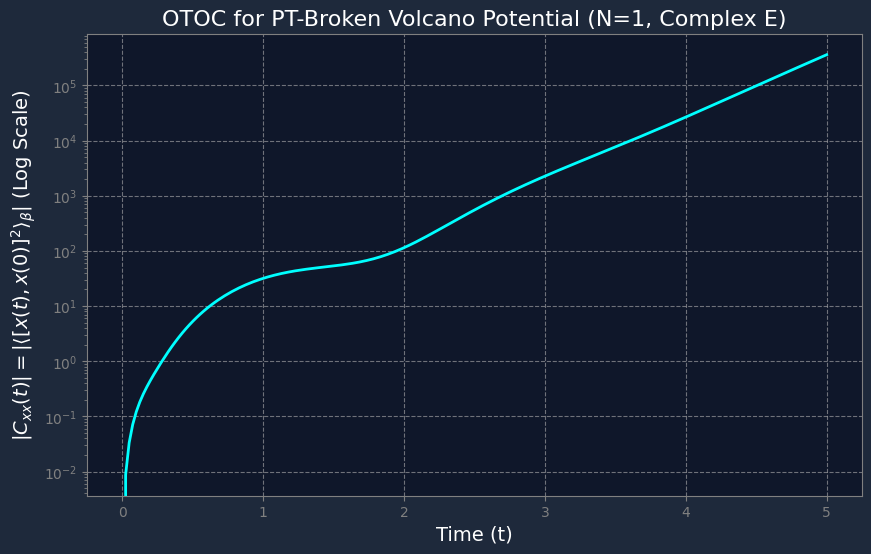

In [ ]:

print("--- Step 1: Normalization (PT-Broken Basis) ---")

norm_1_sq = integrate_complex(lambda x: np.conj(psi_1(x)) * psi_1(x), -np.inf, np.inf)
norm_1 = np.sqrt(norm_1_sq.real)
print(f"Norm of psi_1: {norm_1:.4f}")

phi_1 = lambda x: psi_1(x) / norm_1


overlap_12 = integrate_complex(lambda x: np.conj(phi_1(x)) * psi_2(x), -np.inf, np.inf)
print(f"Overlap <phi_1 | psi_2>: {overlap_12:.4f}")
print("... Applying Gram-Schmidt.")


v2 = lambda x: psi_2(x) - overlap_12 * phi_1(x)

norm_2_sq = integrate_complex(lambda x: np.conj(v2(x)) * v2(x), -np.inf, np.inf)
norm_2 = np.sqrt(norm_2_sq.real)

phi_2 = lambda x: v2(x) / norm_2

BASIS = [phi_1, phi_2]
N_STATES = len(BASIS)


print("\n--- Steps 2 & 3: Calculating X and H Matrices ---")

X_mat = np.zeros((N_STATES, N_STATES), dtype=complex)
H_mat = np.zeros((N_STATES, N_STATES), dtype=complex)


# H_phi_1 = E1 * psi_1 / norm_1 
H_phi_1_func = lambda x: E1 * phi_1(x)
# H_phi_2 = (H(psi_2 - overlap*psi_1)) / norm_2
#          = (E2*psi_2 - overlap*E1*psi_1) / norm_2
H_phi_2_func = lambda x: (E2 * psi_2(x) - overlap_12 * E1 * phi_1(x)) / norm_2

H_BASIS_FUNCS = [H_phi_1_func, H_phi_2_func]

for m in range(N_STATES):
    for n in range(N_STATES):
        phi_m_star_func = lambda x: np.conj(BASIS[m](x))
        
        #X_mn = <m|x|n>
        integrand_X = lambda x: phi_m_star_func(x) * x * BASIS[n](x)
        X_mat[m, n] = integrate_complex(integrand_X, -np.inf, np.inf)

        #H_mn = <m|H|n>
        integrand_H = lambda x: phi_m_star_func(x) * H_BASIS_FUNCS[n](x)
        H_mat[m, n] = integrate_complex(integrand_H, -np.inf, np.inf)

print("X Matrix (Position):")
print(str(np.round(X_mat, 4)))
print(f"Is X Hermitian? {np.allclose(X_mat, X_mat.T.conj())}")

print("\nH Matrix (in orthonormal {phi_1, phi_2} basis):")
print(str(np.round(H_mat, 4)))
print(f"Is H Hermitian? {np.allclose(H_mat, H_mat.T.conj())}")
print("... DIAGNOSTIC: H is NOT Hermitian, as expected.")


eigenvalues, _ = linalg.eig(H_mat)
print(f"\nDiagonalized Eigenvalues: {np.round(eigenvalues, 4)}")
print("... DIAGNOSTIC: The eigenvalues are COMPLEX, as expected!")


print("\n--- Step 4: Calculating Position-Position OTOC (Cxx) ---")

beta = 1.0 
t_values = np.linspace(0, 5, 200) 
otoc_values = []


rho_beta = linalg.expm(-beta * H_mat)
Z = np.trace(rho_beta)
rho_beta_norm = rho_beta / Z
print(f"Calculating C_xx(t) for beta = {beta}...")

for t in t_values:
    # x(t) = exp(i*H*t) @ X @ exp(-i*H*t)
   
    # U(t) = exp(-i*H*t)
    # U_inv(t) = exp(i*H*t)
    U_t = linalg.expm(-1j * H_mat * t)
    U_inv_t = linalg.expm(1j * H_mat * t)
    
   
    # O(t) = U_inv(t) O(0) U(t)
    # x(t) = exp(i*H*t) @ X @ exp(-i*H*t) 
    
    U_t_hermitian_convention = linalg.expm(1j * H_mat * t)
    U_minus_t_hermitian_convention = linalg.expm(-1j * H_mat * t)
    
    X_t = U_t_hermitian_convention @ X_mat @ U_minus_t_hermitian_convention
    
    # Commutator [x(t), x(0)]
    Comm_t = X_t @ X_mat - X_mat @ X_mat
    
    # OTOC operator
    OTOC_op = Comm_t @ Comm_t
    
    # OTOC = -Tr(rho * [x(t), x(0)]^2)
    otoc_value = -np.trace(rho_beta_norm @ OTOC_op)
   
    otoc_values.append(np.abs(otoc_value)) # Plotting magnitude to see growth

print("... Calculation Complete. Generating Plot ...")

# --- 5. Plot Results ---
plt.figure(figsize=(10, 6))
# Plot on a log scale to see exponential growth
plt.semilogy(t_values, otoc_values, lw=2, color='cyan')
plt.xlabel("Time (t)", fontsize=14)
plt.ylabel(r"$|C_{xx}(t)| = | \langle [x(t), x(0)]^2 \rangle_\beta |$ (Log Scale)", fontsize=14)
plt.title(f"OTOC for PT-Broken Volcano Potential (N=1, Complex E)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)

# Set a dark background for the plot
ax = plt.gca()
ax.set_facecolor('#0f172a') # gray-900
plt.gcf().set_facecolor('#1e293b') # gray-800
ax.tick_params(colors='gray', which='both')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('gray')

plt.show()